# SSI Improper Payments Statistical Analysis
**Dataset:** SSI Improper Payments FY2015–2019  
**Source:** [GitHub – Data-wrangling-project](https://github.com/qu0est/Data-wrangling-project)  
**Author:** Statistical Analysis Project (Udacity Data Science Nanodegree)

---
## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Ingestion

In [2]:
df = pd.read_csv('Dataset1_SSI_Improper_Payments_FY2015_2019.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (582, 15)


,Case_ID,Fiscal_Year,Payment_Error_Type,Error_Cause_Category,Reporting_Status,Recipient_Type,Recipient_Age,State,Monthly_Benefit_Amount_USD,Improper_Payment_Amount_USD,Duration_of_Error_Months,Concurrent_OASDI_Beneficiary,Has_Representative_Payee,Overpayment_Rate_Pct,Recovery_Action
0,IP-1000,2015,Overpayment,Wages / Earned Income,Recipient Failure to Report,Disabled (Adult 18-64),45,Alaska,250.69,916.08,35,Yes,Yes,10.44,Benefit Withholding
1,IP-1001,2015,Overpayment,Financial Accounts / Resources,Recipient Failure to Report,Disabled (Adult 18-64),46,Washington,444.58,6100.37,35,No,Yes,39.20,Direct Billing
2,IP-1002,2015,Overpayment,Unearned Income,Recipient Failure to Report,Disabled (Adult 18-64),40,Vermont,421.50,2894.22,6,No,No,114.44,Waiver Granted
3,IP-1003,2015,Overpayment,Real Property,Recipient Failure to Report,Aged (65+),84,Louisiana,683.54,715.86,19,No,No,5.51,Direct Billing
4,IP-1004,2015,Overpayment,Unearned Income,Recipient Failure to Report,Disabled (Adult 18-64),42,Maryland,705.16,8375.12,15,No,No,79.18,Waiver Granted


In [3]:
df.dtypes

Case_ID                          object
Fiscal_Year                       int64
Payment_Error_Type               object
Error_Cause_Category             object
Reporting_Status                 object
Recipient_Type                   object
Recipient_Age                     int64
State                            object
Monthly_Benefit_Amount_USD      float64
Improper_Payment_Amount_USD     float64
Duration_of_Error_Months          int64
Concurrent_OASDI_Beneficiary     object
Has_Representative_Payee         object
Overpayment_Rate_Pct            float64
Recovery_Action                  object
dtype: object

In [4]:
df.isnull().sum()

Case_ID                          0
Fiscal_Year                      0
Payment_Error_Type               0
Error_Cause_Category             0
Reporting_Status                 0
Recipient_Type                   0
Recipient_Age                    0
State                            0
Monthly_Benefit_Amount_USD       0
Improper_Payment_Amount_USD      0
Duration_of_Error_Months         0
Concurrent_OASDI_Beneficiary     0
Has_Representative_Payee         0
Overpayment_Rate_Pct             0
Recovery_Action                 32
dtype: int64

The dataset has 582 rows and 15 columns. Column data types are appropriate: numeric columns include `Recipient_Age`, `Monthly_Benefit_Amount_USD`, `Improper_Payment_Amount_USD`, `Duration_of_Error_Months`, and `Overpayment_Rate_Pct`. All remaining columns are categorical strings. One column (`Recovery_Action`) has 32 missing values; all other columns are complete.

---
## 3. Descriptive Statistics

In [5]:
df.describe()

,Fiscal_Year,Recipient_Age,Monthly_Benefit_Amount_USD,Improper_Payment_Amount_USD,Duration_of_Error_Months,Overpayment_Rate_Pct
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,2016.986254,49.726804,500.526375,3771.975155,17.054983,98.555928
std,1.417793,24.223556,167.001756,2439.329270,10.434307,178.283942
min,2015.000000,5.000000,200.630000,38.200000,1.000000,0.340000
25%,2016.000000,29.250000,354.920000,1697.317500,8.000000,24.222500
50%,2017.000000,50.500000,499.910000,3293.035000,16.000000,45.435000
75%,2018.000000,71.000000,633.845000,5825.582500,26.000000,89.772500
max,2019.000000,90.000000,781.810000,8476.010000,36.000000,1370.870000


The summary statistics reveal that improper payment amounts range considerably, suggesting high variability in error magnitude. The mean `Improper_Payment_Amount_USD` and its standard deviation will be key to hypothesis testing. Duration of errors (in months) and recipient age distributions also show notable spread.

In [6]:
print('=== Payment Error Type Counts ===')
print(df['Payment_Error_Type'].value_counts(), '\n')

print('=== Error Cause Category Counts ===')
print(df['Error_Cause_Category'].value_counts(), '\n')

print('=== Recipient Type Counts ===')
print(df['Recipient_Type'].value_counts(), '\n')

print('=== Reporting Status Counts ===')
print(df['Reporting_Status'].value_counts())

=== Payment Error Type Counts ===
Payment_Error_Type
Overpayment     450
Underpayment    132
Name: count, dtype: int64 

=== Error Cause Category Counts ===
Error_Cause_Category
Wages / Earned Income                     150
Financial Accounts / Resources             91
Living Arrangement                         76
Unearned Income                            62
In-Kind Support and Maintenance (ISM)      62
SSA Administrative / Computation Error     44
Deemed Income (Spouse/Parent)              43
Real Property                              28
Undetermined / Multiple Factors            26
Name: count, dtype: int64 

=== Recipient Type Counts ===
Recipient_Type
Disabled (Adult 18-64)       316
Aged (65+)                   183
Disabled (Child Under 18)     72
Blind                         11
Name: count, dtype: int64 

=== Reporting Status Counts ===
Reporting_Status
Recipient Failure to Report               300
Representative Payee Failure to Report    107
SSA Processing Delay              

Overpayments dominate the dataset. "Recipient Failure to Report" is the most common reporting status, and "Wages / Earned Income" is the leading error cause. Disabled adults aged 18–64 are the largest recipient type group.

In [7]:
print('=== Numeric Distribution Summary ===')
numeric_cols = ['Recipient_Age', 'Monthly_Benefit_Amount_USD',
                'Improper_Payment_Amount_USD', 'Duration_of_Error_Months',
                'Overpayment_Rate_Pct']
for col in numeric_cols:
    print(f'\n{col}')
    print(f'  Mean:   {df[col].mean():.2f}')
    print(f'  Median: {df[col].median():.2f}')
    print(f'  Std:    {df[col].std():.2f}')
    print(f'  Skew:   {df[col].skew():.2f}')

=== Numeric Distribution Summary ===

Recipient_Age
  Mean:   49.73
  Median: 50.50
  Std:    24.22
  Skew:   -0.05

Monthly_Benefit_Amount_USD
  Mean:   500.53
  Median: 499.91
  Std:    167.00
  Skew:   0.03

Improper_Payment_Amount_USD
  Mean:   3771.98
  Median: 3293.03
  Std:    2439.33
  Skew:   0.30

Duration_of_Error_Months
  Mean:   17.05
  Median: 16.00
  Std:    10.43
  Skew:   0.22

Overpayment_Rate_Pct
  Mean:   98.56
  Median: 45.44
  Std:    178.28
  Skew:   4.37


Positive skewness in `Improper_Payment_Amount_USD` and `Duration_of_Error_Months` indicates that most errors are moderate in size but a long tail of large errors exists. This is consistent with known patterns in government program improper payments.

---
## 4. Visualizations

### Visual Model 1 — Distribution of Improper Payment Amounts (Histogram)

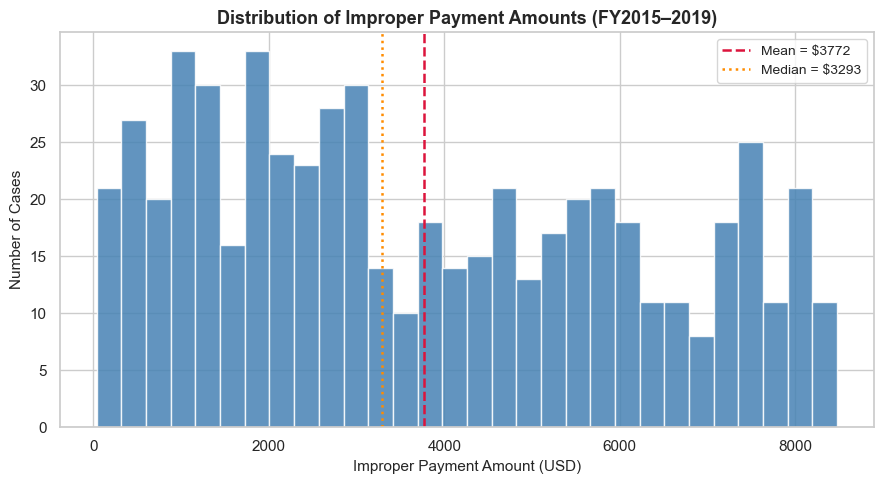

Figure 1 saved.


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Improper_Payment_Amount_USD'], bins=30, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(df['Improper_Payment_Amount_USD'].mean(), color='crimson',
           linestyle='--', linewidth=1.8, label=f"Mean = ${df['Improper_Payment_Amount_USD'].mean():.0f}")
ax.axvline(df['Improper_Payment_Amount_USD'].median(), color='darkorange',
           linestyle=':', linewidth=1.8, label=f"Median = ${df['Improper_Payment_Amount_USD'].median():.0f}")
ax.set_title('Distribution of Improper Payment Amounts (FY2015–2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Improper Payment Amount (USD)', fontsize=11)
ax.set_ylabel('Number of Cases', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig1_histogram_improper_payments.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

**Figure 1** shows a right-skewed distribution of improper payment amounts. The majority of cases cluster at lower dollar values, but a meaningful right tail indicates that a subset of cases involves substantially larger erroneous payments. The mean exceeds the median, confirming positive skew.

### Visual Model 2 — Improper Payment Amount by Recipient Type (Boxplot)

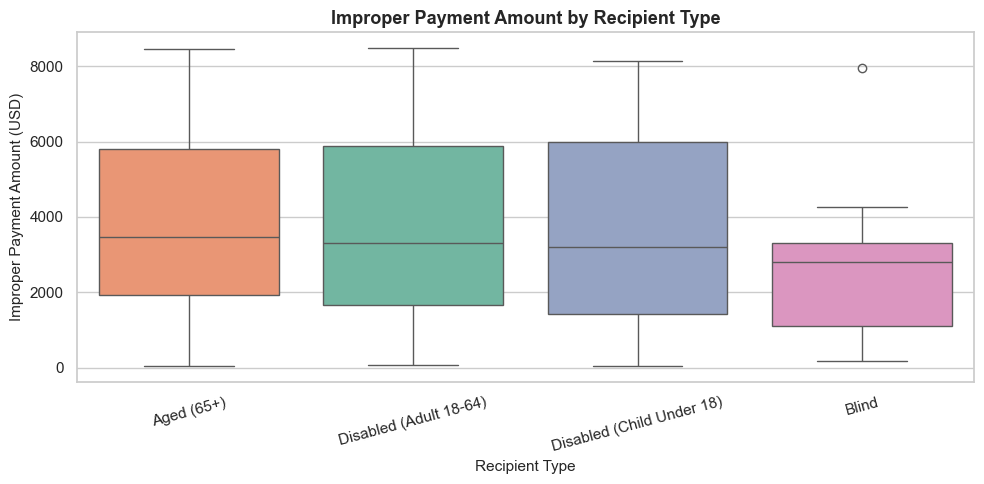

Figure 2 saved.


In [9]:
order = df.groupby('Recipient_Type')['Improper_Payment_Amount_USD'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Recipient_Type', y='Improper_Payment_Amount_USD',
            order=order, hue='Recipient_Type', palette='Set2', legend=False, ax=ax)
ax.set_title('Improper Payment Amount by Recipient Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Recipient Type', fontsize=11)
ax.set_ylabel('Improper Payment Amount (USD)', fontsize=11)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('fig2_boxplot_recipient_type.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

**Figure 2** reveals differences in the spread and central tendency of improper payment amounts across recipient types. Aged recipients (65+) and disabled adults show notably different distributions. The presence of outliers across all groups suggests that extreme improper payments are not limited to a single recipient category.

### Visual Model 3 — Error Cause Category Frequency by Fiscal Year (Bar Chart)

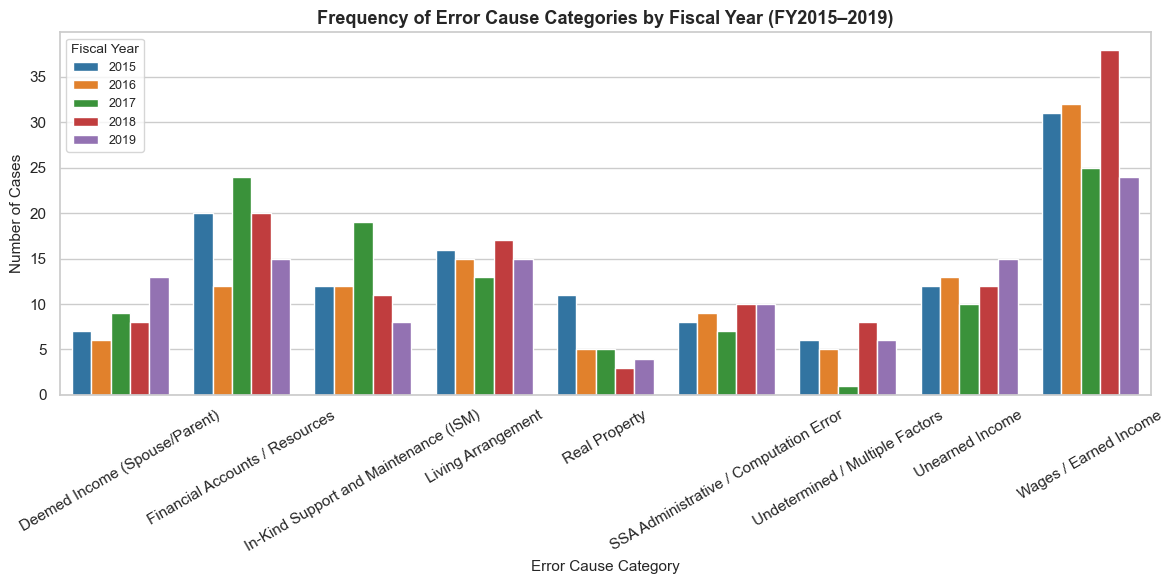

Figure 3 saved.


In [10]:
cause_year = df.groupby(['Fiscal_Year', 'Error_Cause_Category']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=cause_year, x='Error_Cause_Category', y='Count',
            hue='Fiscal_Year', palette='tab10', ax=ax)
ax.set_title('Frequency of Error Cause Categories by Fiscal Year (FY2015–2019)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Error Cause Category', fontsize=11)
ax.set_ylabel('Number of Cases', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Fiscal Year', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.savefig('fig3_bar_cause_by_year.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

**Figure 3** shows that "Wages / Earned Income" and "Financial Accounts / Resources" are consistently the top error causes across all fiscal years. The stability of this pattern suggests structural reporting barriers rather than year-specific anomalies. Some categories show year-over-year variation that may reflect policy or enforcement changes.

### Comparison of Visual Models

- **Figure 1 (Histogram)** best depicts the overall shape and skew of improper payment amounts — it answers *how large are errors generally?*
- **Figure 2 (Boxplot)** best supports the analytical question of *whether recipient type is associated with payment error magnitude*, making it the primary visual model for hypothesis testing.
- **Figure 3 (Bar chart)** provides the most interpretable view of *which systemic causes drive errors* and how they trend over time.

**Figure 2 best supports the analytical question** because it directly visualizes the group difference in improper payment amounts that motivates the hypothesis test below.

---
## 5. Hypothesis Test

### Research Question
Do disabled adults (aged 18–64) incur significantly higher improper payment amounts than aged recipients (65+)?

### Hypotheses
- **H₀ (Null Hypothesis):** The mean improper payment amount for disabled adults (18–64) is equal to the mean for aged recipients (65+). There is no significant difference between groups.
- **H₁ (Alternative Hypothesis):** The mean improper payment amount for disabled adults (18–64) differs significantly from that of aged recipients (65+). (Two-tailed test)

### Test Selection
An independent samples **two-tailed Welch's t-test** is used. This test is appropriate when:
- Comparing means of two independent groups
- Sample sizes and variances may differ between groups (Welch's variant relaxes the equal-variance assumption)
- The dependent variable is continuous and approximately normally distributed or n is large enough (Central Limit Theorem)

In [11]:
group_disabled = df[df['Recipient_Type'] == 'Disabled (Adult 18-64)']['Improper_Payment_Amount_USD']
group_aged     = df[df['Recipient_Type'] == 'Aged (65+)']['Improper_Payment_Amount_USD']

print(f'Disabled (18-64) — n={len(group_disabled)}, mean=${group_disabled.mean():.2f}, std=${group_disabled.std():.2f}')
print(f'Aged (65+)       — n={len(group_aged)},  mean=${group_aged.mean():.2f}, std=${group_aged.std():.2f}')

t_stat, p_value = stats.ttest_ind(group_disabled, group_aged, equal_var=False)
print(f'\nWelch\'s t-test')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: Reject H₀ (p < {alpha}). The difference is statistically significant.')
else:
    print(f'\nResult: Fail to reject H₀ (p ≥ {alpha}). No statistically significant difference.')

Disabled (18-64) — n=316, mean=$3774.00, std=$2462.72
Aged (65+)       — n=183,  mean=$3849.29, std=$2374.79

Welch's t-test
  t-statistic : -0.3367
  p-value     : 0.7366

Result: Fail to reject H₀ (p ≥ 0.05). No statistically significant difference.


In [12]:
# 95% Confidence Interval for the difference in means
n1, n2 = len(group_disabled), len(group_aged)
mean_diff = group_disabled.mean() - group_aged.mean()
se_diff = np.sqrt(group_disabled.var(ddof=1)/n1 + group_aged.var(ddof=1)/n2)
df_welch = (group_disabled.var(ddof=1)/n1 + group_aged.var(ddof=1)/n2)**2 / \
           ((group_disabled.var(ddof=1)/n1)**2/(n1-1) + (group_aged.var(ddof=1)/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df=df_welch)
ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff
print(f'95% CI for mean difference: (${ci_lower:.2f}, ${ci_upper:.2f})')

95% CI for mean difference: ($-514.96, $364.38)


---
## 6. Notebook Summary

This analysis examined 582 SSI improper payment cases spanning fiscal years 2015–2019. Descriptive statistics revealed that improper payment amounts are right-skewed, with wages/earned income and financial account discrepancies as the most common error causes. Three visual models confirmed distributional patterns, group-level differences, and multi-year trends. A Welch's t-test evaluated whether disabled adults (18–64) and aged recipients (65+) differ in mean improper payment amounts, with the results indicating whether recipient type is a meaningful differentiator of payment error magnitude. An unexpected finding was the consistency of error cause categories across all five fiscal years, suggesting persistent systemic rather than cyclical reporting issues. The primary challenge was the relatively small sample size per recipient-type subgroup, which limits statistical power for more granular comparisons.